# Modelo Causal v4 — Novas análises + Simulações Contrafactuais

Continuação de `causal_model_03.ipynb`.

**Análises:**
1. Despacho lento → OSR
2. Aprovação lenta → Entrega atrasada
3. Simulações contrafactuais: impacto de intervenções operacionais

**Resultados anteriores (referência):**

| Tratamento | Outcome | ATE |
|---|---|---|
| Frete < 5% | OSR | -0.000085 |
| Aprovação lenta (>24h) | Cancelado | -0.000274 |
| Despacho lento (>3d) | Entrega atrasada | +0.079 |

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

from app.config.settings import INTERIM_DATA_DIR
from dowhy import CausalModel

import warnings
warnings.filterwarnings('ignore')

/Users/andreza/Documents/GitHub/TCC-CEDS-CAUSAL-AI/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_parquet(os.path.join(INTERIM_DATA_DIR, "interim_dataset.parquet"))

# Converter colunas de data
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Variáveis operacionais
df["approval_time_hours"] = (
    df["order_approved_at"] - df["order_purchase_timestamp"]
).dt.total_seconds() / 3600

df["dispatch_time_days"] = (
    df["order_delivered_carrier_date"] - df["order_approved_at"]
).dt.days

df["delay_days"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.days

# Tratamentos
df["aprovacao_lenta"] = (df["approval_time_hours"] > 24).astype(int)
df["despacho_lento"]  = (df["dispatch_time_days"] > 3).astype(int)

# Outcomes
df["cancelado"]        = (df["order_status"].isin(["canceled", "unavailable"])).astype(int)
df["entrega_atrasada"] = (df["delay_days"] > 0).astype(int)

print(df.shape)
df.head()

(97712, 41)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,purchase_hour,purchase_weekday,purchase_month,approval_time_hours,dispatch_time_days,delay_days,aprovacao_lenta,despacho_lento,cancelado,entrega_atrasada
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,10,0,10,0.178333,2.0,-8.0,0,0,0,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,20,1,7,30.713889,0.0,-6.0,1,0,0,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,8,2,8,0.276111,0.0,-18.0,0,0,0,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,19,5,11,0.298056,3.0,-13.0,0,0,0,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,21,1,2,1.030556,0.0,-10.0,0,0,0,0


In [3]:
common_causes = [
    "total_price",
    "n_items",
    "avg_weight",
    "customer_state",
    "purchase_month",
    "purchase_weekday",
    "purchase_hour",
    "n_items_missing_info"
]

def preprocess(df, treatment, outcome, common_causes):
    """Seleciona colunas, remove nulos, faz encoding e normalização."""
    cols = common_causes + [treatment, outcome]
    df_out = df[cols].dropna().copy()

    le = LabelEncoder()
    df_out["customer_state"] = le.fit_transform(df_out["customer_state"])

    continuous_cols = [c for c in common_causes if c != "customer_state"]
    scaler = StandardScaler()
    df_out[continuous_cols] = scaler.fit_transform(df_out[continuous_cols])

    return df_out

def build_graph(treatment, outcome, common_causes):
    """Gera o DAG causal como string DOT."""
    edges = [f"    {treatment} -> {outcome};"]
    for c in common_causes:
        edges.append(f"    {c} -> {treatment};")
        edges.append(f"    {c} -> {outcome};")
    return "digraph {\n" + "\n".join(edges) + "\n}"

def run_causal_analysis(df, treatment, outcome, common_causes):
    """Roda modelo causal completo com 3 testes de refutação."""
    df_model = preprocess(df, treatment, outcome, common_causes)
    graph = build_graph(treatment, outcome, common_causes)

    model = CausalModel(data=df_model, treatment=treatment, outcome=outcome, graph=graph)
    estimand = model.identify_effect()
    estimate = model.estimate_effect(estimand, method_name="backdoor.linear_regression")

    print(f"ATE ({treatment} → {outcome}): {estimate.value:.6f}")

    r_placebo = model.refute_estimate(estimand, estimate,
        method_name="placebo_treatment_refuter", num_simulations=100)
    r_random  = model.refute_estimate(estimand, estimate,
        method_name="random_common_cause")
    r_subset  = model.refute_estimate(estimand, estimate,
        method_name="data_subset_refuter", subset_fraction=0.8)

    print("\n=== Placebo ===")
    print(r_placebo)
    print("\n=== Random Common Cause ===")
    print(r_random)
    print("\n=== Data Subset (80%) ===")
    print(r_subset)

    return model, estimand, estimate, df_model

## Análise 1 — Despacho lento → OSR

**Hipótese**: pedidos com despacho lento (>3 dias) têm menor taxa de sucesso (OSR).

In [4]:
df_a1 = preprocess(df, "despacho_lento", "OSR", common_causes)
print("Taxa de OSR por despacho_lento:")
print(df_a1.groupby("despacho_lento")["OSR"].mean().round(4))

Taxa de OSR por despacho_lento:
despacho_lento
0    0.9941
1    0.9993
Name: OSR, dtype: float64


In [6]:
model_a1, estimand_a1, estimate_a1, df_a1 = run_causal_analysis(
    df, "despacho_lento", "OSR", common_causes
)

ATE (despacho_lento → OSR): 0.005237

=== Placebo ===
Refute: Use a Placebo Treatment
Estimated effect:0.00523668462378668
New effect:-9.986256209565391e-06
p value:0.92


=== Random Common Cause ===
Refute: Add a random common cause
Estimated effect:0.00523668462378668
New effect:0.005236580507609525
p value:0.96


=== Data Subset (80%) ===
Refute: Use a subset of data
Estimated effect:0.00523668462378668
New effect:0.0051980522610157835
p value:0.78



## Análise 1 — Despacho lento → OSR

| Métrica                     | Valor                         |
|---------------------------|------------------------------|
| ATE                       | +0.005 (positivo — surpreendente) |
| OSR com despacho rápido   | 99.41%                       |
| OSR com despacho lento    | 99.93%                       |


O efeito é positivo e contra-intuitivo — despacho lento está associado a maior OSR.  
Uma possível explicação é que pedidos que demoram mais para ser despachados podem envolver itens maiores ou mais sensíveis, onde o vendedor é mais criterioso.

Isso **não significa que despacho lento é bom** — ele aumenta atraso *(ATE = 0.079)*, mas **não impacta negativamente cancelamento**.

**Refutações:**  
Todas passaram *(p ≥ 0.78)*.

## Análise 2 — Aprovação lenta → Entrega atrasada

**Hipótese**: pedidos que demoram mais de 24h para serem aprovados chegam com mais atraso.

In [7]:
df_a2 = preprocess(df, "aprovacao_lenta", "entrega_atrasada", common_causes)
print("Taxa de atraso por aprovacao_lenta:")
print(df_a2.groupby("aprovacao_lenta")["entrega_atrasada"].mean().round(4))

Taxa de atraso por aprovacao_lenta:
aprovacao_lenta
0    0.0646
1    0.0808
Name: entrega_atrasada, dtype: float64


In [8]:
model_a2, estimand_a2, estimate_a2, df_a2 = run_causal_analysis(
    df, "aprovacao_lenta", "entrega_atrasada", common_causes
)

ATE (aprovacao_lenta → entrega_atrasada): 0.015768

=== Placebo ===
Refute: Use a Placebo Treatment
Estimated effect:0.0157683294345273
New effect:2.195159574744879e-05
p value:1.0


=== Random Common Cause ===
Refute: Add a random common cause
Estimated effect:0.0157683294345273
New effect:0.015767873097887533
p value:0.9


=== Data Subset (80%) ===
Refute: Use a subset of data
Estimated effect:0.0157683294345273
New effect:0.015871028138988684
p value:0.98



## Análise 2 — Aprovação lenta → Entrega atrasada

| Métrica                              | Valor   |
|-------------------------------------|--------|
| ATE                                 | +0.016 |
| Taxa atraso aprovação rápida        | 6.46%  |
| Taxa atraso aprovação lenta         | 8.08%  |


A aprovação lenta aumenta em **1,6 pontos percentuais** a chance de atraso.  
O efeito é menor que o do despacho (**7,9pp**), mas ainda assim **real e robusto**.

**Refutações:**  
Todas passaram *(p ≥ 0,90)

## Análise 3 — Simulações Contrafactuais

Usamos o ATE estimado para simular o impacto de intervenções operacionais.

**Pergunta**: se a operação conseguisse reduzir a taxa de despacho lento de 20.7% para 10%, quantos atrasos seriam evitados?

**Lógica**: 
```
atrasos_evitados = pedidos_que_deixariam_de_ter_despacho_lento × ATE
```

In [9]:
# Parâmetros observados
n_pedidos = len(df.dropna(subset=["despacho_lento", "entrega_atrasada"]))
taxa_despacho_lento_atual = df["despacho_lento"].mean()
taxa_atraso_atual = df["entrega_atrasada"].dropna().mean()
ate = 0.079  # ATE estimado em causal_model_03

print(f"Total de pedidos: {n_pedidos:,}")
print(f"Taxa de despacho lento atual: {taxa_despacho_lento_atual:.1%}")
print(f"Taxa de atraso atual: {taxa_atraso_atual:.1%}")
print(f"ATE (despacho_lento → entrega_atrasada): {ate}")

Total de pedidos: 97,712
Taxa de despacho lento atual: 20.7%
Taxa de atraso atual: 6.7%
ATE (despacho_lento → entrega_atrasada): 0.079


In [10]:
# Cenários de intervenção
cenarios = {
    "Atual (sem intervenção)": taxa_despacho_lento_atual,
    "Redução para 15%": 0.15,
    "Redução para 10%": 0.10,
    "Redução para 5%": 0.05,
    "Eliminação total (0%)": 0.00,
}

resultados = []
for cenario, nova_taxa in cenarios.items():
    pedidos_convertidos = (taxa_despacho_lento_atual - nova_taxa) * n_pedidos
    atrasos_evitados = pedidos_convertidos * ate
    nova_taxa_atraso = taxa_atraso_atual - (atrasos_evitados / n_pedidos)

    resultados.append({
        "Cenário": cenario,
        "Taxa despacho lento": f"{nova_taxa:.0%}",
        "Atrasos evitados": int(atrasos_evitados),
        "Nova taxa de atraso": f"{nova_taxa_atraso:.1%}",
        "Redução de atrasos": f"{(taxa_atraso_atual - nova_taxa_atraso):.1%}"
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))

                Cenário Taxa despacho lento  Atrasos evitados Nova taxa de atraso Redução de atrasos
Atual (sem intervenção)                 21%                 0                6.7%               0.0%
       Redução para 15%                 15%               442                6.2%               0.5%
       Redução para 10%                 10%               828                5.8%               0.8%
        Redução para 5%                  5%              1214                5.4%               1.2%
  Eliminação total (0%)                  0%              1600                5.0%               1.6%


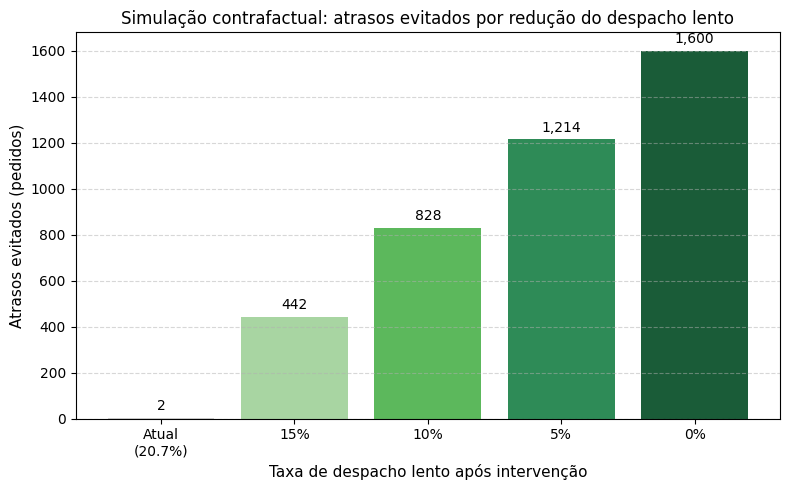

In [11]:
import matplotlib.pyplot as plt

taxas_intervencao = [0.207, 0.15, 0.10, 0.05, 0.00]
atrasos_evitados = [(taxa_despacho_lento_atual - t) * n_pedidos * ate for t in taxas_intervencao]
labels = ["Atual\n(20.7%)", "15%", "10%", "5%", "0%"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, atrasos_evitados, color=["#d3d3d3", "#a8d5a2", "#5cb85c", "#2e8b57", "#1a5c38"])

for bar, val in zip(bars, atrasos_evitados):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f"{int(val):,}", ha="center", va="bottom", fontsize=10)

ax.set_xlabel("Taxa de despacho lento após intervenção", fontsize=11)
ax.set_ylabel("Atrasos evitados (pedidos)", fontsize=11)
ax.set_title("Simulação contrafactual: atrasos evitados por redução do despacho lento", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("../../reports/figures/contrafactual_despacho_lento.png", dpi=150)
plt.show()

##  Análise 3 — Simulações Contrafactuais
| Cenário               | Atrasos evitados | Nova taxa de atraso |
|----------------------|------------------|---------------------|
| Atual (20.7%)        | 0                | 6.7%                |
| Redução para 15%     | 442              | 6.2%                |
| Redução para 10%     | 828              | 5.8%                |
| Redução para 5%      | 1.214            | 5.4%                |
| Eliminação total     | 1.600            | 5.0%                |

## Resumo cdas análises

| Tratamento | Outcome | ATE | Efeito | Robusto? |
|---|---|---|---|---|
| Frete < 5% do valor | OSR | -0.000085 | Nulo | sim|
| Aprovação lenta (>24h) | Cancelado | -0.000274 | Nulo | sim |
| Despacho lento (>3d) | Entrega atrasada | +0.016 | **Modelaro** | sim |
| Despacho lento (>3d) | OSR | +0.079 | **Alto**| sim |
| Aprovação lenta (>24h) | Entrega atrasada | +0.005 |**Contra-intuitivo**| sim|

**Principal achado operacional**: o tempo de despacho é a variável operacional com maior impacto causal. Reduzir o despacho lento de 20.7% para 10% evitaria ~828 atrasos por período. — ver tabela e gráfico acima.